# Phase 10: Genre Combination Analysis

This phase analyzes relationships between multiple genres assigned to movies.

The analysis focuses on:
- Extracting genre combinations
- Identifying the most common genre pairs
- Analyzing genre combinations across decades
- Studying genre relationships and co-occurrence patterns

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from itertools import combinations

df = pd.read_csv("../data/processed/movies_feature_engineered.csv")

print("Dataset Shape:", df.shape)
display(df.head())

Dataset Shape: (569655, 46)


,tconst,titleType,primaryTitle,startYear,runtimeMinutes,genres,genre_list,averageRating,numVotes,year,...,genre_sport,genre_talk_show,genre_thriller,genre_war,genre_western,runtime_category,rating_category,log_votes,popularity_category,rating_popularity_score
0,tt0000574,movie,The Story of the Kelly Gang,1906,70.0,"Action,Adventure,Biography","['Action', 'Adventure', 'Biography']",6.0,1084.0,1906,...,0,0,0,0,0,Short,Average,6.989335,Popular,41.936012
1,tt0000591,movie,The Prodigal Son,1907,90.0,Drama,['Drama'],4.8,40.0,1907,...,0,0,0,0,0,Medium,Low,3.713572,Low,17.825146
2,tt0000615,movie,Robbery Under Arms,1907,NaN,Drama,['Drama'],3.4,36.0,1907,...,0,0,0,0,0,Unknown,Low,3.610918,Low,12.277121
3,tt0000630,movie,Hamlet,1908,NaN,Drama,['Drama'],3.0,42.0,1908,...,0,0,0,0,0,Unknown,Low,3.761200,Low,11.283600
4,tt0000675,movie,Don Quijote,1908,NaN,Drama,['Drama'],3.8,32.0,1908,...,0,0,0,0,0,Unknown,Low,3.496508,Low,13.286729


### 10.1 Genre Data Preparation

Movies can belong to multiple genres. The genre list is therefore converted into individual genre combinations for co-occurrence analysis.

In [2]:
genre_data = df[
    ["tconst", "decade", "genre_list"]
].dropna().copy()

print("Movies with genre information:", len(genre_data))

display(genre_data.head())

Movies with genre information: 569655


,tconst,decade,genre_list
0,tt0000574,1900,"['Action', 'Adventure', 'Biography']"
1,tt0000591,1900,['Drama']
2,tt0000615,1900,['Drama']
3,tt0000630,1900,['Drama']
4,tt0000675,1900,['Drama']


In [3]:
genre_pairs = []

for _, row in genre_data.iterrows():
    genres = row["genre_list"]
    
    if isinstance(genres, str):
        genres = genres.strip("[]").replace("'", "").split(",")
        genres = [g.strip() for g in genres if g.strip()]
    
    # Remove duplicates and sort genres
    genres = sorted(set(genres))
    
    # Generate all unique genre pairs
    for genre1, genre2 in combinations(genres, 2):
        genre_pairs.append({
            "tconst": row["tconst"],
            "decade": row["decade"],
            "genre1": genre1,
            "genre2": genre2
        })

genre_pairs_df = pd.DataFrame(genre_pairs)

print("Total Genre Pair Records:", len(genre_pairs_df))

display(genre_pairs_df.head(20))

Total Genre Pair Records: 417541


,tconst,decade,genre1,genre2
0,tt0000574,1900,Action,Adventure
1,tt0000574,1900,Action,Biography
2,tt0000574,1900,Adventure,Biography
3,tt0000679,1900,Adventure,Fantasy
4,tt0001049,1900,Drama,War
5,tt0001175,1910,Drama,Romance
6,tt0001184,1910,Adventure,Drama
7,tt0001285,1900,Biography,Drama
8,tt0001285,1900,Biography,Family
9,tt0001285,1900,Drama,Family


### 10.2 Most Common Genre Combinations

Genre pairs are ranked based on the number of movies in which both genres occur together.

In [4]:
pair_counts = (
    genre_pairs_df
    .groupby(["genre1", "genre2"])
    .size()
    .reset_index(name="movie_count")
    .sort_values("movie_count", ascending=False)
)

print("Top Genre Combinations:")

display(pair_counts.head(20))

Top Genre Combinations:


,genre1,genre2,movie_count
111,Comedy,Drama,29482
178,Drama,Romance,27876
131,Crime,Drama,20038
7,Action,Drama,16766
123,Comedy,Romance,16366
182,Drama,Thriller,12670
5,Action,Crime,9944
90,Biography,Documentary,9703
1,Action,Adventure,8386
4,Action,Comedy,7576


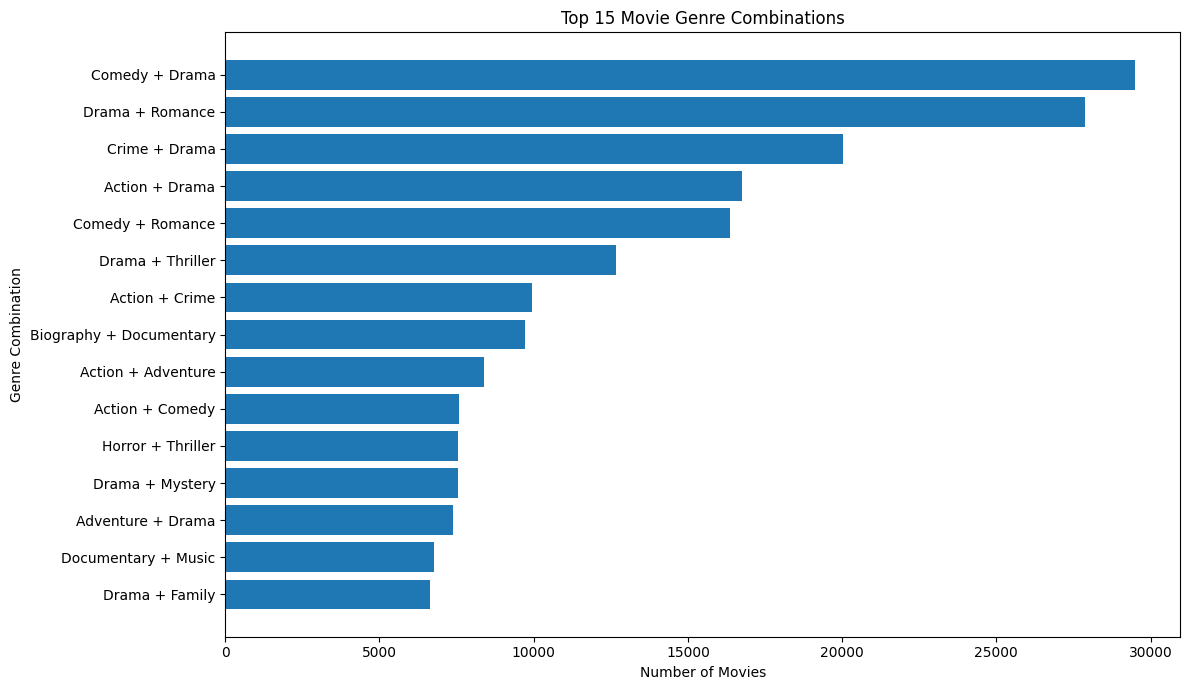

In [5]:
top_pairs = pair_counts.head(15).copy()

top_pairs["combination"] = (
    top_pairs["genre1"] + " + " + top_pairs["genre2"]
)

plt.figure(figsize=(12, 7))

plt.barh(
    top_pairs["combination"][::-1],
    top_pairs["movie_count"][::-1]
)

plt.xlabel("Number of Movies")
plt.ylabel("Genre Combination")
plt.title("Top 15 Movie Genre Combinations")

plt.tight_layout()
plt.show()

### 10.3 Genre Combination Evolution Across Decades

This analysis examines how popular genre combinations have changed across different decades.

In [6]:
decade_pairs = (
    genre_pairs_df
    .groupby(["decade", "genre1", "genre2"])
    .size()
    .reset_index(name="movie_count")
)

decade_pairs["combination"] = (
    decade_pairs["genre1"] + " + " + decade_pairs["genre2"]
)

display(
    decade_pairs
    .sort_values("movie_count", ascending=False)
    .head(20)
)

,decade,genre1,genre2,movie_count,combination
2056,2010,Comedy,Drama,9148,Comedy + Drama
2118,2010,Drama,Romance,6305,Drama + Romance
2036,2010,Biography,Documentary,6212,Biography + Documentary
2324,2020,Comedy,Drama,5432,Comedy + Drama
1808,2000,Comedy,Drama,4525,Comedy + Drama
2121,2010,Drama,Thriller,4332,Drama + Thriller
2066,2010,Comedy,Romance,4304,Comedy + Romance
2094,2010,Documentary,History,4207,Documentary + History
2074,2010,Crime,Drama,4136,Crime + Drama
2090,2010,Documentary,Drama,3972,Documentary + Drama


In [7]:
top_by_decade = (
    decade_pairs
    .sort_values(
        ["decade", "movie_count"],
        ascending=[True, False]
    )
    .groupby("decade")
    .head(5)
)

display(top_by_decade)

,decade,genre1,genre2,movie_count,combination
10,1900,Documentary,Sport,9,Documentary + Sport
9,1900,Documentary,News,4,Documentary + News
5,1900,Biography,Drama,3,Biography + Drama
11,1900,Documentary,War,3,Documentary + War
16,1900,News,Sport,3,News + Sport
...,...,...,...,...,...
2324,2020,Comedy,Drama,5432,Comedy + Drama
2385,2020,Drama,Romance,3389,Drama + Romance
2389,2020,Drama,Thriller,3242,Drama + Thriller
2343,2020,Crime,Drama,2758,Crime + Drama


In [8]:
top_combinations = (
    pair_counts
    .head(5)
    .assign(
        combination=lambda x:
        x["genre1"] + " + " + x["genre2"]
    )["combination"]
    .tolist()
)

trend_data = decade_pairs[
    decade_pairs["combination"].isin(top_combinations)
]

trend_pivot = trend_data.pivot_table(
    index="decade",
    columns="combination",
    values="movie_count",
    aggfunc="sum",
    fill_value=0
)

display(trend_pivot)

combination,Action + Drama,Comedy + Drama,Comedy + Romance,Crime + Drama,Drama + Romance
decade,,,,,
1910,74,429,128,469,436
1920,444,559,459,547,1145
1930,434,768,1039,1044,1522
1940,318,715,781,869,995
1950,566,987,777,1405,1545
1960,1152,1140,949,1376,2071
1970,1681,1465,773,1627,2037
1980,2024,1830,870,1541,2060
1990,2053,2484,1351,1944,2528


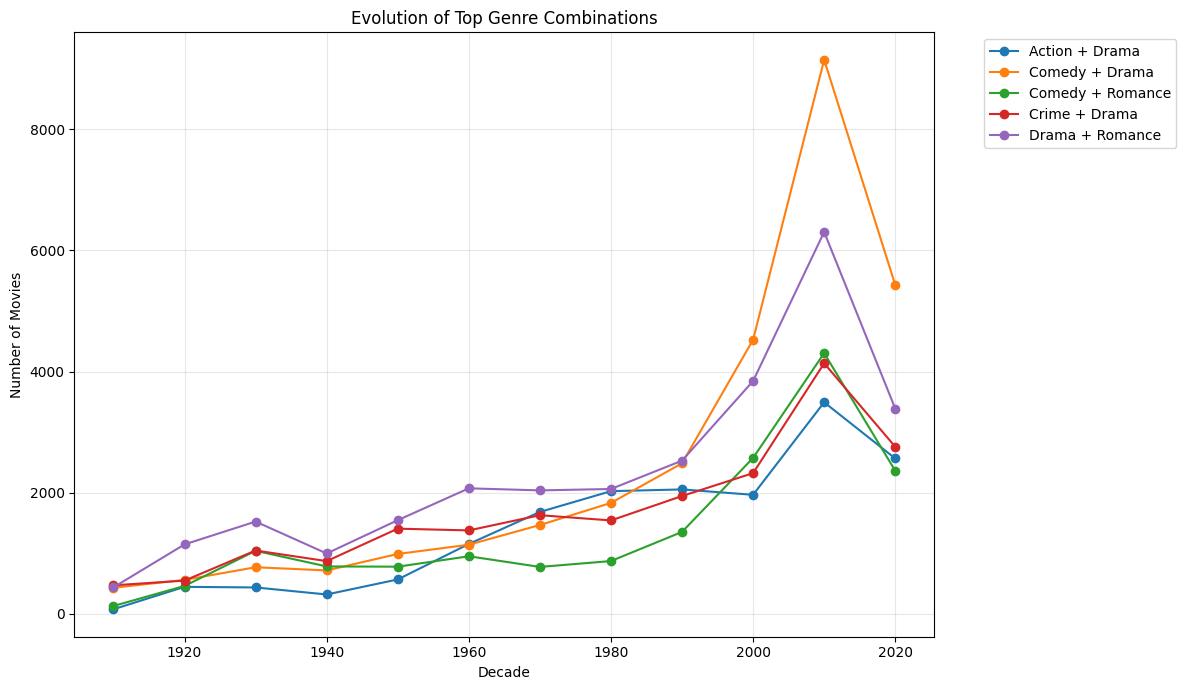

In [9]:
plt.figure(figsize=(12, 7))

for combination in trend_pivot.columns:
    plt.plot(
        trend_pivot.index,
        trend_pivot[combination],
        marker="o",
        label=combination
    )

plt.xlabel("Decade")
plt.ylabel("Number of Movies")
plt.title("Evolution of Top Genre Combinations")

plt.legend(
    bbox_to_anchor=(1.05, 1),
    loc="upper left"
)

plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [10]:
cooccurrence = pd.crosstab(
    genre_pairs_df["genre1"],
    genre_pairs_df["genre2"]
)

print("Genre Co-occurrence Matrix Shape:", cooccurrence.shape)

display(cooccurrence)

Genre Co-occurrence Matrix Shape: (26, 26)


genre2,Adult,Adventure,Animation,Biography,Comedy,Crime,Documentary,Drama,Family,Fantasy,...,Mystery,News,Reality-TV,Romance,Sci-Fi,Sport,Talk-Show,Thriller,War,Western
genre1,,,,,,,,,,,,,,,,,,,,,
Action,47,8386,1536,500,7576,9944,588,16766,562,1956,...,960,8,8,2235,2114,380,0,5226,1006,415
Adult,0,50,18,11,979,266,82,739,1,142,...,66,0,1,296,51,14,2,73,2,26
Adventure,0,0,2779,635,5939,1834,2271,7387,2762,2275,...,575,41,9,1316,1016,354,0,758,382,313
Animation,0,0,0,214,2067,146,480,1099,1373,696,...,80,4,0,96,362,72,0,46,27,5
Biography,0,0,0,0,915,715,9703,5699,576,77,...,51,99,17,343,14,634,2,71,252,17
Comedy,0,0,0,0,0,6117,2077,29482,4628,3672,...,1717,27,27,16366,1708,856,12,1974,506,708
Crime,0,0,0,0,0,0,1164,20038,284,308,...,3845,34,2,1681,213,94,1,6391,83,87
Documentary,0,0,0,0,0,0,0,5580,1891,214,...,301,1324,85,265,149,3215,22,133,1599,23
Drama,0,0,0,0,0,0,0,0,6629,4583,...,7551,150,10,27876,2193,1942,3,12670,5212,6289


In [11]:
# 10.11 Save Genre Combination Analysis Results

pair_counts.to_csv(
    "../data/processed/genre_pair_counts.csv",
    index=False
)

decade_pairs.to_csv(
    "../data/processed/genre_pairs_by_decade.csv",
    index=False
)

cooccurrence.to_csv(
    "../data/processed/genre_cooccurrence_matrix.csv"
)

print("Genre combination analysis files saved successfully.")

Genre combination analysis files saved successfully.


## Key Insights

### Genre Combination Findings

- Movies frequently combine multiple genres rather than belonging to a single genre.
- The most common genre combinations reveal recurring storytelling patterns in cinema.
- Genre combinations vary substantially across different decades.
- Some genre pairings become more prominent in later decades, indicating changes in audience preferences and filmmaking trends.
- Co-occurrence analysis identifies genres that frequently appear together.
- The evolution of genre combinations provides a more detailed view of cinema trends than analyzing individual genres alone.

In [12]:
# 10.13 Top Genre Combination Summary

print("===== GENRE COMBINATION ANALYSIS SUMMARY =====")

top_pair = pair_counts.iloc[0]

print(
    f"Most common genre combination: "
    f"{top_pair['genre1']} + {top_pair['genre2']}"
)

print(
    f"Movies containing this combination: "
    f"{int(top_pair['movie_count'])}"
)

print("\nTop 10 Genre Combinations:")

display(
    pair_counts
    .head(10)
    .reset_index(drop=True)
)

===== GENRE COMBINATION ANALYSIS SUMMARY =====
Most common genre combination: Comedy + Drama
Movies containing this combination: 29482

Top 10 Genre Combinations:


,genre1,genre2,movie_count
0,Comedy,Drama,29482
1,Drama,Romance,27876
2,Crime,Drama,20038
3,Action,Drama,16766
4,Comedy,Romance,16366
5,Drama,Thriller,12670
6,Action,Crime,9944
7,Biography,Documentary,9703
8,Action,Adventure,8386
9,Action,Comedy,7576


## Genre Combination Analysis Conclusion

Genre combination analysis reveals how multiple genres are frequently blended within movies to create diverse storytelling formats.

The analysis identifies the most common genre pairings and demonstrates that genre combinations have evolved over time. Certain combinations become increasingly prominent in specific periods, reflecting changes in filmmaking styles, audience preferences, and cinematic trends.

The decade-level analysis provides evidence that genre relationships are not static and that the structure of multi-genre storytelling has changed throughout the history of cinema.

Overall, genre combination analysis complements the earlier genre evolution analysis by examining not only which genres are popular, but also how different genres interact and appear together within movies.